CLASSIFICATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
don = pd.read_csv("donclassif.txt", header=0, sep=";")
don.head()
print(don.shape)
print(don.describe)

(2800, 2)
<bound method NDFrame.describe of             V1        V2
0     6.002504  0.031505
1     6.004021  0.063168
2     6.004545  0.094957
3     6.004069  0.126843
4     6.002587  0.158794
...        ...       ...
2795  1.223519  5.870877
2796 -0.472344  4.910527
2797  0.961090  5.183866
2798  0.067021  5.228207
2799  0.138501  4.122749

[2800 rows x 2 columns]>


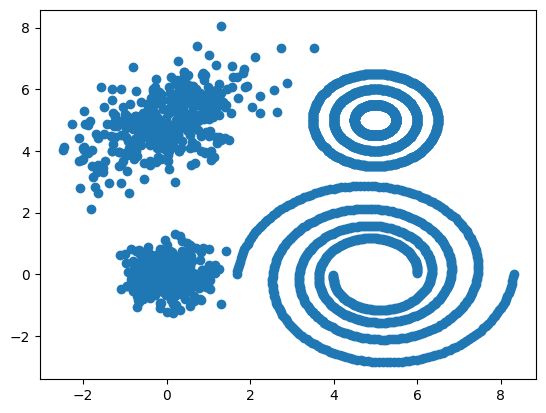

In [3]:
plt.plot(don["V1"],don["V2"],'o')
plt.show()

In [19]:
from sklearn.cluster import KMeans
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

5    610
3    598
4    437
2    397
0    391
1    367
Name: count, dtype: int64

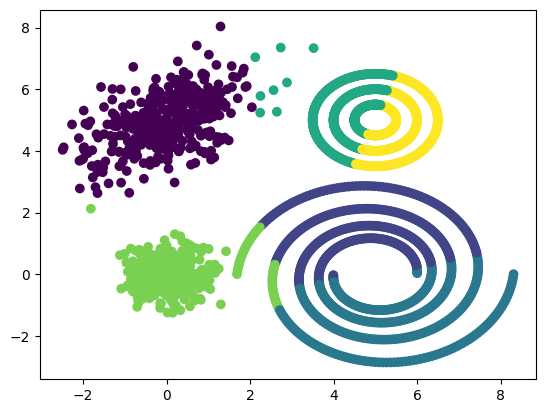

In [20]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

0    709
3    565
4    414
5    394
1    361
2    357
Name: count, dtype: int64


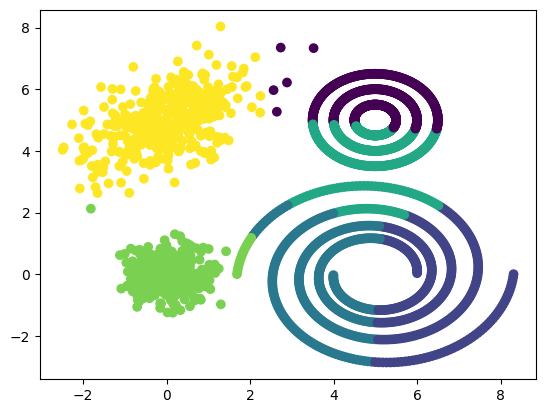

In [21]:
tmp = KMeans(n_clusters=6, n_init=1,init='random').fit(don)
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
print(pd.Series(tmp.labels_).value_counts())
plt.show()

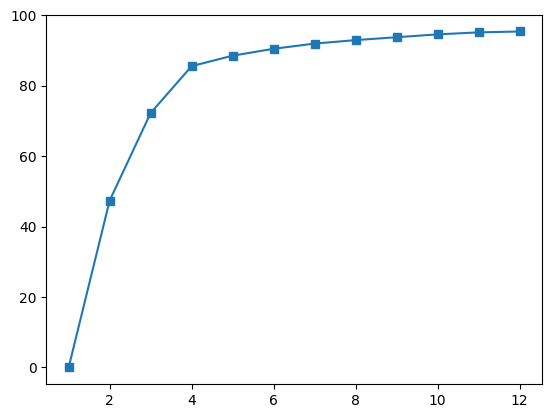

In [22]:
rapport = np.zeros(12)
inertietot = KMeans(n_clusters=1, n_init=10).fit(don)
inertietot = inertietot.inertia_
### car je ne sais pas retrouver l'inertie totale
for ii in range(1, 13):
    toto = KMeans(n_clusters=ii, n_init=10,init='random').fit(don)
    rapport[ii-1] = 100-round(toto.inertia_ / inertietot * 100, 2)
### je fais 100 moins pour avoir l'évolution croissante qui est à mon avis plus facile àlire
plt.plot(range(1, 13), rapport, marker='s')
plt.show()

je choisis 4 groupes

In [23]:
tmp = KMeans(n_clusters=4, n_init=100,init='random').fit(don)
pd.Series(tmp.labels_).value_counts()

1    1244
3     708
0     454
2     394
Name: count, dtype: int64

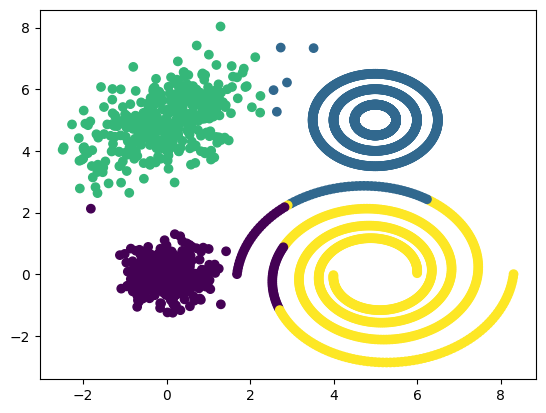

In [24]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.show()

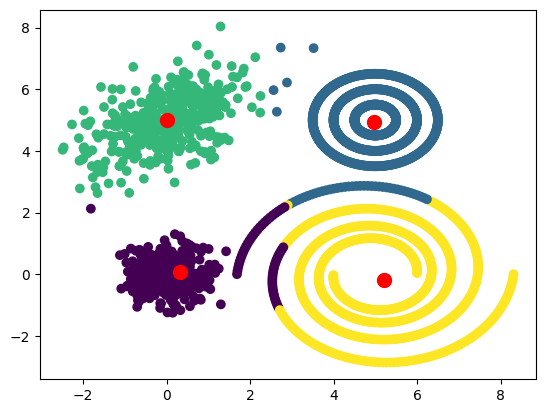

In [29]:
plt.scatter(don["V1"],don["V2"],c=tmp.labels_)
plt.scatter(tmp.cluster_centers_[:,0],tmp.cluster_centers_[:,1], color="red", s=100)
plt.show()